# Stock market trend prediction

### This project focuses on analyzing Tesla’s stock price time series to detect and forecast market trends (bullish, bearish, or neutral). It begins with traditional statistical and technical indicator methods, then progressively integrates advanced machine learning and deep learning algorithms to improve the accuracy and responsiveness of trend detection. The outcome is a comparative study and prototype capable of automatically identifying the current trend and predicting potential reversals.

By Thomas Jin, Thibault Gauthé, Yijia Zhang

In [2]:
import pandas as pd
import ta
import seaborn as sns
import numpy as np
from math import ceil
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# Data Collection

In [3]:
data = pd.read_csv('Tesla_stock_data.csv')
data.head()

,Date,Close,High,Low,Open,Volume
0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500
1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500
2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000
3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000
4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500


### Data Overview

In [4]:
print("Shape:", data.shape)

Shape: (3843, 6)


In [5]:
print("\nColumns and dtypes:\n", data.dtypes)


Columns and dtypes:
 Date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [6]:
print("\nFirst 5 rows:")
print(data.head())
print("\nLast 5 rows:")
print(data.tail())


First 5 rows:
         Date     Close      High       Low      Open     Volume
0  2010-06-29  1.592667  1.666667  1.169333  1.266667  281494500
1  2010-06-30  1.588667  2.028000  1.553333  1.719333  257806500
2  2010-07-01  1.464000  1.728000  1.351333  1.666667  123282000
3  2010-07-02  1.280000  1.540000  1.247333  1.533333   77097000
4  2010-07-06  1.074000  1.333333  1.055333  1.333333  103003500

Last 5 rows:
            Date       Close        High         Low        Open     Volume
3838  2025-10-01  459.459991  462.290009  440.750000  443.799988   98122300
3839  2025-10-02  436.000000  470.750000  435.570007  470.540009  137009000
3840  2025-10-03  429.829987  446.769989  416.579987  443.290009  133188200
3841  2025-10-06  453.250000  453.549988  436.690002  440.750000   85324900
3842  2025-10-07  433.089996  452.679993  432.450012  447.820007  101798300


In [7]:
print("\nMissing values (count):\n", data.isnull().sum())


Missing values (count):
 Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [8]:
data.duplicated().sum()

0

In [9]:
print("\nDescriptive statistics:\n", data.describe().T)


Descriptive statistics:
          count          mean           std           min           25%  \
Close   3843.0  9.388797e+01  1.186940e+02  1.053333e+00  1.269167e+01   
High    3843.0  9.599240e+01  1.214350e+02  1.108667e+00  1.288867e+01   
Low     3843.0  9.168992e+01  1.158776e+02  9.986670e-01  1.240900e+01   
Open    3843.0  9.391116e+01  1.187844e+02  1.076000e+00  1.261367e+01   
Volume  3843.0  9.699445e+07  7.621392e+07  1.777500e+06  5.086650e+07   

                 50%           75%           max  
Close   1.945400e+01  2.007400e+02  4.798600e+02  
High    1.988800e+01  2.045917e+02  4.885400e+02  
Low     1.911600e+01  1.952133e+02  4.575100e+02  
Open    1.948333e+01  2.004667e+02  4.759000e+02  
Volume  8.339850e+07  1.222820e+08  9.140820e+08  


We can see that the brut dataset has no missing values nor duplicates so at this point we don't have nothing to clean

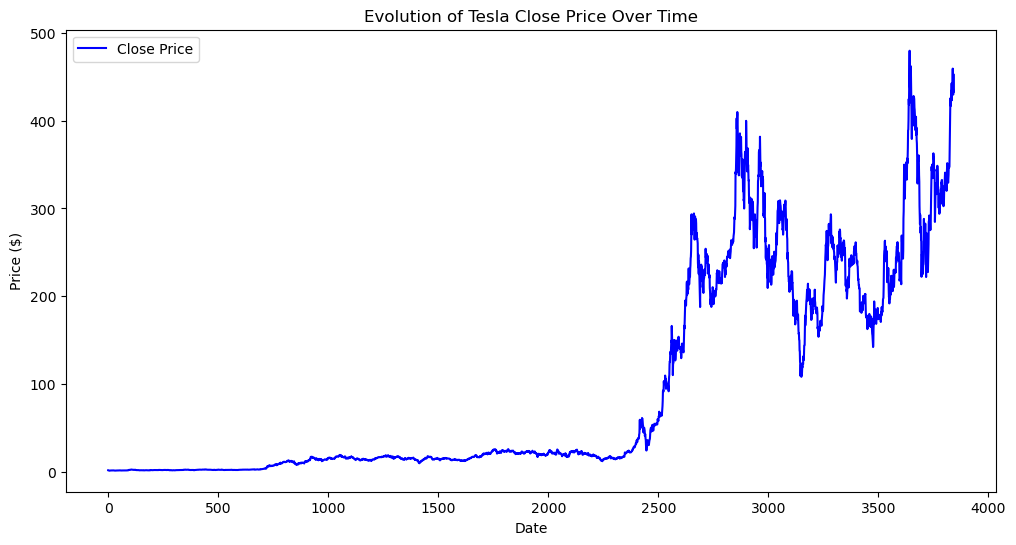

In [10]:
plt.figure(figsize=(12,6))
plt.plot(data["Close"], label="Close Price", color="blue")
plt.title("Evolution of Tesla Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

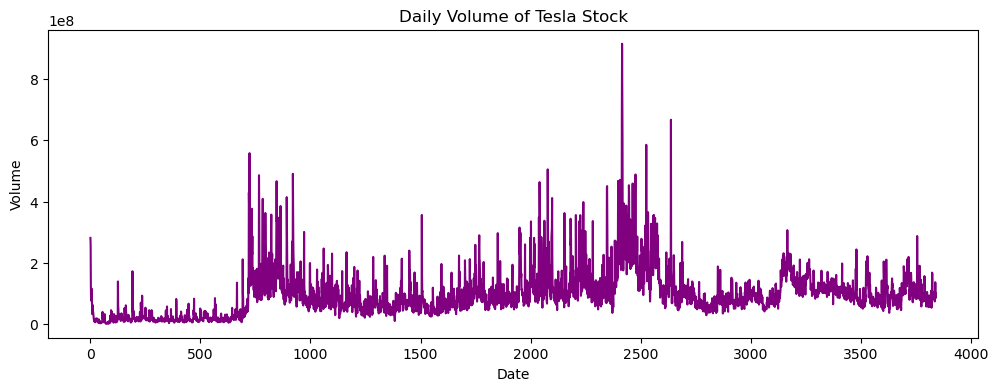

In [11]:
plt.figure(figsize=(12,4))
plt.plot(data["Volume"], color="purple")
plt.title("Daily Volume of Tesla Stock")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

# Data Preparation for EDA

### Coherence verification

In [12]:
data = data.sort_index() # Sort the data by index to ensure chronological order
print(data.index.is_monotonic_increasing) # Verify that the index is sorted in increasing order (should return True)

True


In [13]:
# Check for rows where High is less than Low

invalid = data[data["High"] < data["Low"]]
print(invalid.head())

Empty DataFrame
Columns: [Date, Close, High, Low, Open, Volume]
Index: []


In [14]:
# Check for invalid values in Volume column

print((data["Volume"] <= 0).sum())

0


In [15]:
# Check for extreme daily returns (e.g., greater than 50% in absolute value)
data["Return_1d"] = data["Close"].pct_change()
print((data["Return_1d"].abs() > 0.5).sum())

0


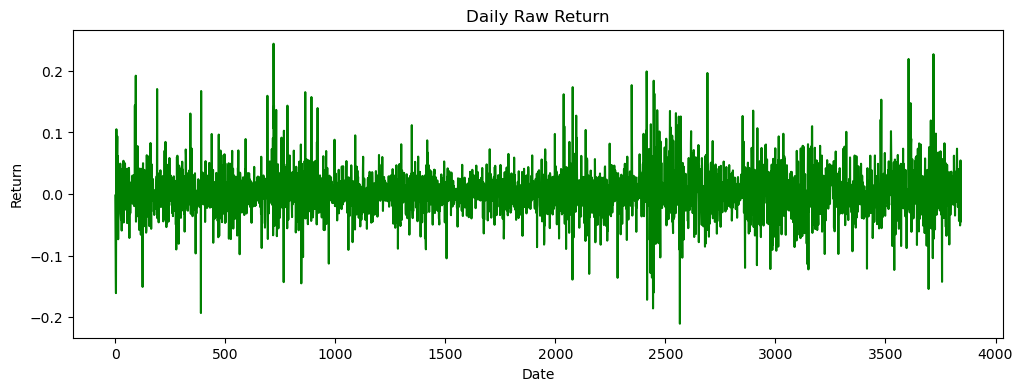

In [16]:
plt.figure(figsize=(12,4))
plt.plot(data["Return_1d"], color="green")
plt.title("Daily Raw Return")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

### Analysis of Daily Returns

The daily return plot shows the volatility and price fluctuations of Tesla stock over time. We observe several key patterns:

- **High volatility periods**: There are notable spikes in both positive and negative returns, indicating periods of significant market movements
- **Volatility clustering**: Periods of high volatility tend to cluster together, which is typical for stock market data
- **Extreme events**: Some returns exceed ±20%, suggesting major announcements or market events affecting Tesla's stock price
- **Recent patterns**: The more recent data (right side of the plot) shows continued volatility, reflecting Tesla's dynamic market behavior

This return series will be essential for our trend prediction models, as it captures the momentum and volatility characteristics that often precede trend changes.

### Feature engineering

In [17]:
# Let's convert the 'Date' column to datetime format and set it as the index
data['Date'] = pd.to_datetime(data['Date'], format='%Y-%m-%d')
data = data.sort_values('Date')
data = data.set_index('Date')

In [18]:
# Here we will create new features that could help our model to predict trends better

# moving averages : the meaning of the closing prices over a specific period
data["MA50"] = data["Close"].rolling(50).mean()
data["MA200"] = data["Close"].rolling(200).mean()

# rolling volatility : it measures the price fluctuations over a specific period
data["Volatility_20d"] = data["Return_1d"].rolling(20).std()

# Relative Strength Index (RSI) : it indicates whether a stock is overbought or oversold
data["RSI_14"] = ta.momentum.rsi(data["Close"], window=14)

In [19]:
# Now, we will create the target variable 'Trend' by comparing the closing price of the next day with the current day

data["Trend"] = (data["Close"].shift(-1) > data["Close"]).astype(int) # 1 if bullish day, 0 if bearish day

In [20]:
print(data.head())

               Close      High       Low      Open     Volume  Return_1d  \
Date                                                                       
2010-06-29  1.592667  1.666667  1.169333  1.266667  281494500        NaN   
2010-06-30  1.588667  2.028000  1.553333  1.719333  257806500  -0.002511   
2010-07-01  1.464000  1.728000  1.351333  1.666667  123282000  -0.078473   
2010-07-02  1.280000  1.540000  1.247333  1.533333   77097000  -0.125683   
2010-07-06  1.074000  1.333333  1.055333  1.333333  103003500  -0.160937   

            MA50  MA200  Volatility_20d  RSI_14  Trend  
Date                                                    
2010-06-29   NaN    NaN             NaN     NaN      0  
2010-06-30   NaN    NaN             NaN     NaN      0  
2010-07-01   NaN    NaN             NaN     NaN      0  
2010-07-02   NaN    NaN             NaN     NaN      0  
2010-07-06   NaN    NaN             NaN     NaN      0  


We can see here that some value are missing because in order to get those you have to get the values of the 50/200 previous one

### Final cleaning step

In [21]:
data = data.dropna()
print(data.isnull().sum())

Close             0
High              0
Low               0
Open              0
Volume            0
Return_1d         0
MA50              0
MA200             0
Volatility_20d    0
RSI_14            0
Trend             0
dtype: int64


In [22]:
print(data.head())
print(data.tail())

               Close      High       Low      Open    Volume  Return_1d  \
Date                                                                      
2011-04-12  1.643333  1.680667  1.620000  1.672000  20361000  -0.024535   
2011-04-13  1.662000  1.712667  1.654000  1.675333  18172500   0.011359   
2011-04-14  1.676000  1.685333  1.613333  1.658000  14751000   0.008424   
2011-04-15  1.705333  1.745333  1.694000  1.710000  14152500   0.017502   
2011-04-18  1.668667  1.708000  1.624000  1.675333  15508500  -0.021501   

                MA50     MA200  Volatility_20d     RSI_14  Trend  
Date                                                              
2011-04-12  1.597293  1.581757        0.045385  49.263004      1  
2011-04-13  1.598653  1.582103        0.045344  50.769372      1  
2011-04-14  1.600253  1.582540        0.045328  51.922269      1  
2011-04-15  1.602853  1.583747        0.045404  54.335217      0  
2011-04-18  1.604947  1.585690        0.045693  50.896591      1  
     

# Exploratory Analysis (EDA)

### Feature Distributions

In [23]:
# Calculate advanced technical indicators like ADX, MACD

# 1. Calculate Average Directional Index (ADX)
data["ADX"] = ta.trend.adx(high=data["High"], low=data["Low"], close=data["Close"])

# MACD is a trend-following momentum indicator.
macd_indicator = ta.trend.MACD(close=data["Close"])
data["MACD"] = macd_indicator.macd()

# 3. Calculate Bollinger Bands
bollinger_indicator = ta.volatility.BollingerBands(close=data["Close"])
data["BBL_High"] = bollinger_indicator.bollinger_hband()
data["BBL_Low"] = bollinger_indicator.bollinger_lband()

# 4. Check if columns are added
print("Columns added:", ['ADX', 'MACD', 'BBL_High', 'BBL_Low'])
print(data[['ADX', 'MACD']].tail())

Columns added: ['ADX', 'MACD', 'BBL_High', 'BBL_Low']
                  ADX       MACD
Date                            
2025-10-01  43.356807  27.814025
2025-10-02  44.378655  26.300916
2025-10-03  43.678070  24.323512
2025-10-06  43.276686  24.365336
2025-10-07  42.562176  22.512231


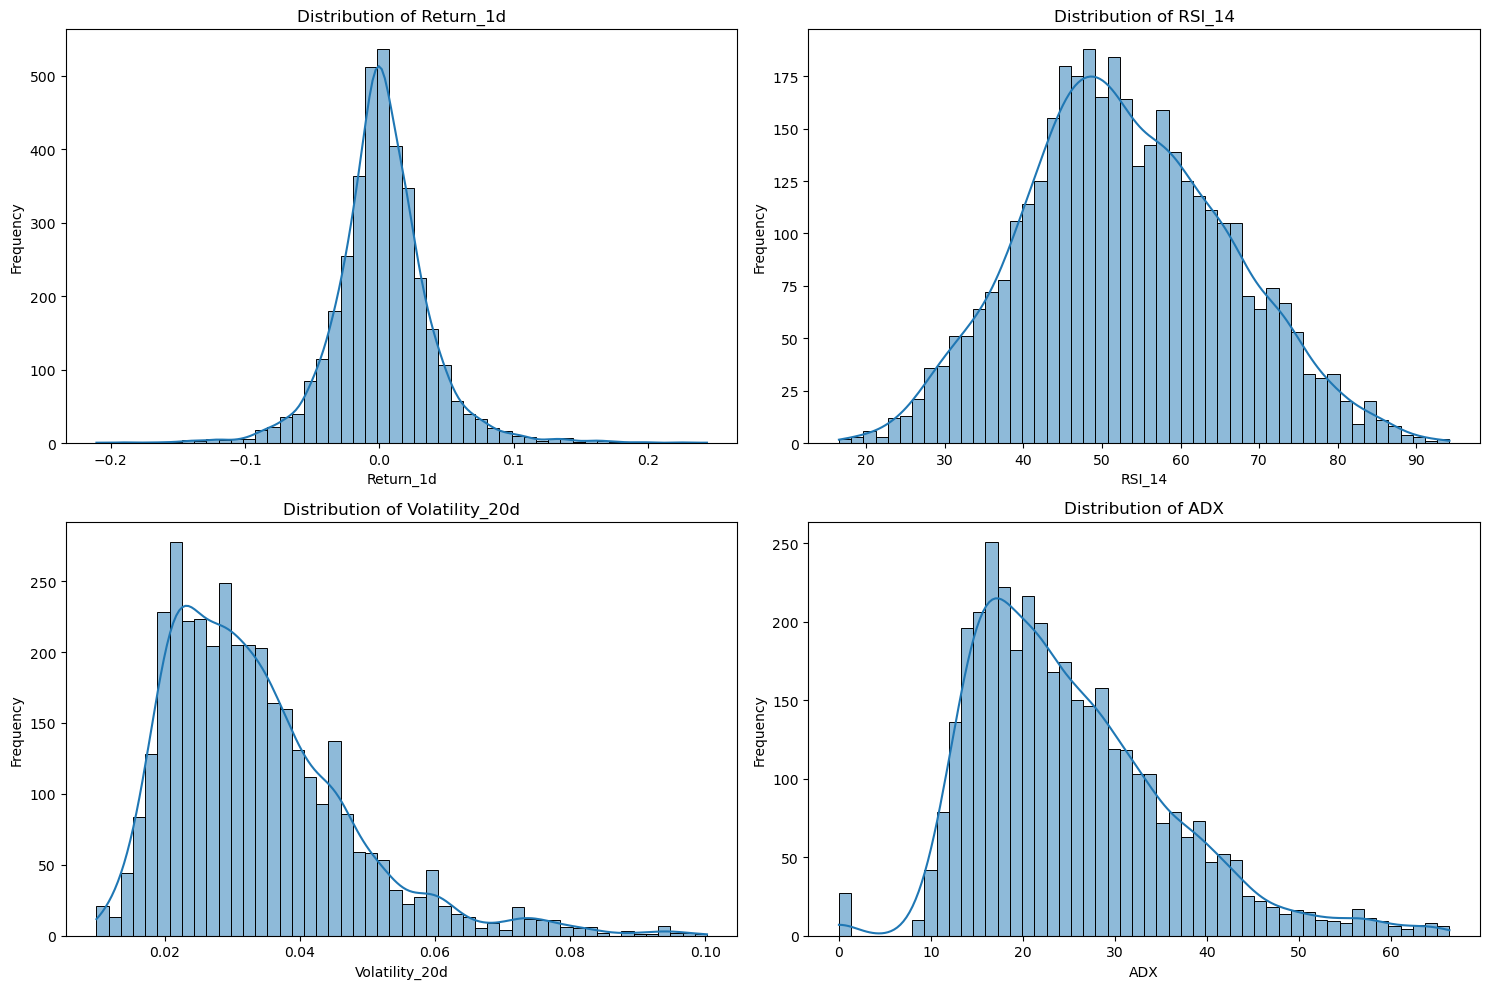

In [24]:
# List of features to visualize
features_to_plot = ['Return_1d', 'RSI_14', 'Volatility_20d', 'ADX']

# Create a figure with subplots
plt.figure(figsize=(15, 10))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    
    # Check if the column exists to avoid KeyError
    if feature in data.columns:
        # Plot histogram with kernel density estimate
        sns.histplot(data[feature].dropna(), kde=True, bins=50)
        plt.title(f'Distribution of {feature}')
        plt.xlabel(feature)
        plt.ylabel('Frequency')
    else:
        print(f"Warning: {feature} not found in data.")

plt.tight_layout()
plt.show()

### Overal Analysis:

1.Return_1d

Mostly stable, but with occasional extreme price jumps (fat tails).

2.RSI_14

Mostly in the normal range; extreme overbought or oversold conditions are rare.

3.Volatility_20d

Usually low volatility, with only rare spikes in market risk.

4.ADX

Strong trends are uncommon; the market is mostly sideways or weak.

Summary

The asset is mostly stable and range-bound with few strong trends, but prone to occasional extreme volatility.

### Correlation Heatmap 

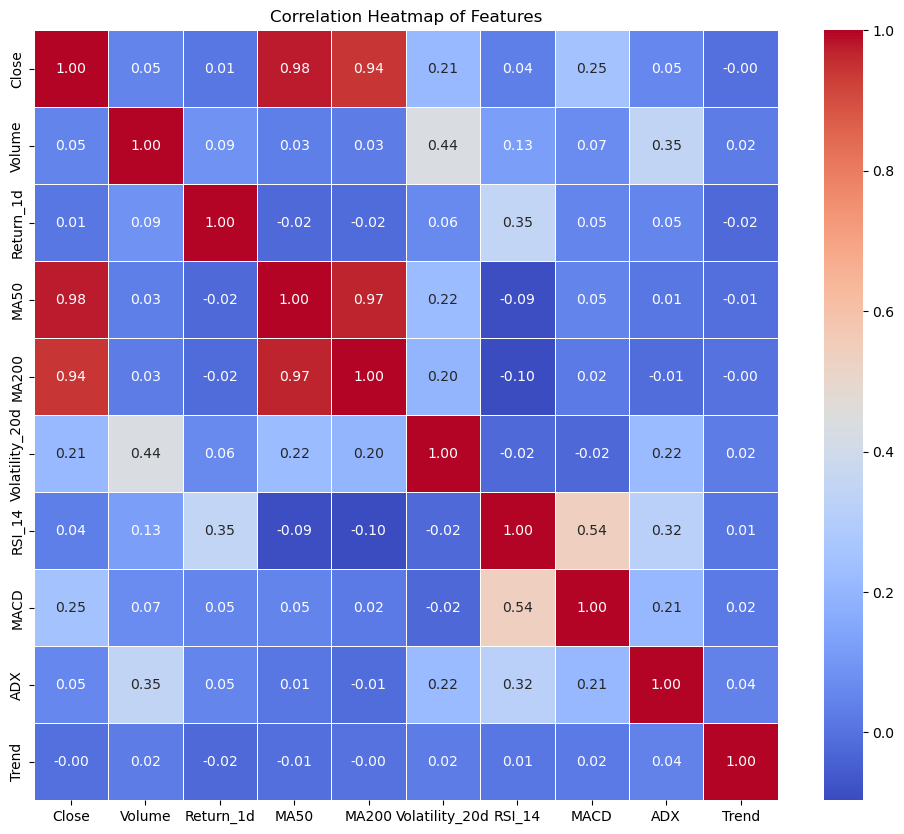

In [25]:
# Select numerical columns for correlation analysis
cols_for_corr = ['Close', 'Volume', 'Return_1d', 'MA50', 'MA200',
                 'Volatility_20d', 'RSI_14', 'MACD', 'ADX', 'Trend']

# Calculate correlation matrix
corr_matrix = data[cols_for_corr].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.show()

### Overall Analysis：

1.Weak Target Correlation

The target variable Trend shows extremely weak correlations with all other features (all values are close to 0, e.g., 0.02, -0.01).

Conclusion: No single technical indicator has a strong linear relationship with the future trend. This explains why simple linear models (like Logistic Regression) struggled and confirms the need for non-linear models (like Random Forest, XGBoost) to capture complex patterns.

2.Strong Multi-collinearity

Close, MA50, and MA200 are highly correlated (0.94 - 0.98).

Conclusion: These features carry very similar information. Including all of them might introduce redundancy, potentially confusing some models, though tree-based models usually handle this well.

3.Moderate Correlations

RSI_14 shows a moderate positive correlation with MACD (0.54) and Return_1d (0.35), which makes sense as they all reflect momentum.

Volume has a moderate correlation with Volatility_20d (0.44), indicating that higher trading volume often accompanies higher price volatility.

Summary:

The heatmap highlights that price trends are not linearly predictable using these standard indicators alone. The high redundancy among price-based features (Close, MA) suggests feature selection or engineering (e.g., using ratios like Price/MA instead of raw values) could be beneficial. The lack of direct correlation with Trend reinforces the difficulty of the prediction task.

### Trend Analysis with Moving Averages

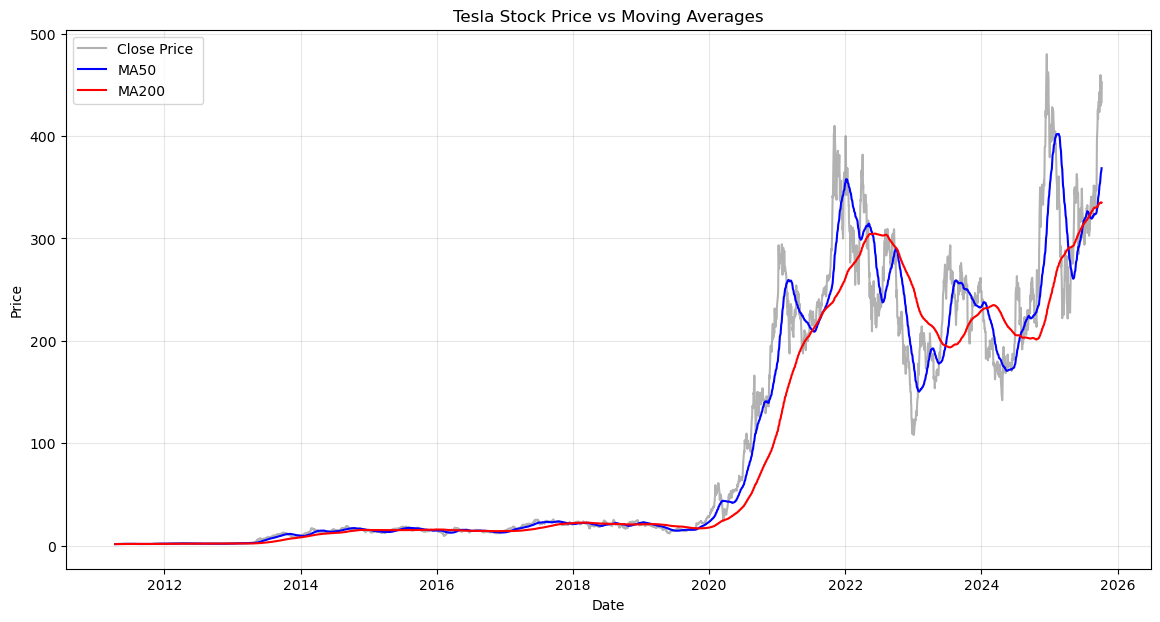

In [26]:
# Visualize the stock price along with 50-day and 200-day Moving Averages to identify long-term trends.

plt.figure(figsize=(14, 7))

# Plot Closing Price
plt.plot(data.index, data['Close'], label='Close Price ', alpha=0.6, color='gray')

# Plot Moving Averages
plt.plot(data.index, data['MA50'], label='MA50', color='blue', linewidth=1.5)
plt.plot(data.index, data['MA200'], label='MA200', color='red', linewidth=1.5)

plt.title('Tesla Stock Price vs Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Trend Analysis with Moving Averages

1.Overall Trend:

The stock price (Close Price) shows significant long-term growth, especially from 2020 onwards. The exponential rise in 2020-2021 is clearly captured by the moving averages lagging behind the price.

2.MA50 vs MA200 (Golden Cross & Death Cross:

Golden Cross: When the blue line (MA50) crosses above the red line (MA200), it signals a potential bullish trend (e.g., around late 2019/early 2020).

Death Cross: When the blue line crosses below the red line, it signals a potential bearish trend (e.g., in 2022).

3.Current State:

Recently, the price is highly volatile. The MA50 is fluctuating around the MA200, indicating a period of consolidation or uncertainty, though the price seems to be currently above both averages, suggesting recent strength.

Summary

The chart confirms that Tesla is a high-growth but high-volatility stock. Moving averages effectively smooth out noise to reveal the underlying trend direction.。

# Data preparation for modeling

### Train Test Split

Before normalizing for base models like logistic regression, we will split the dataset into two parts: the training set and the test set. We will not shuffle the data because we are working with time series data, where the chronological order must be preserved to avoid data leakage and ensure realistic model evaluation.

In [27]:
features = ["Return_1d", "MA50", "MA200", "Volatility_20d", "RSI_14"]
target = "Trend"

In [28]:
# in order to avoid data leakage, we will split the data into training and testing sets based on a specific date
# and not by using the train_test_split function because it shuffles the data by default
# We will use data up to 2022-12-31 for training and data from 2023-01-01 for testing (80-20 split)
train = data.loc[: "2022-12-31"]
test = data.loc["2023-01-01":]

In [29]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [30]:
# Verify that there is no overlap between training and testing sets
print(X_train.shape, X_test.shape)
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

assert train.index.max() < test.index.min()

(2951, 5) (693, 5)
2011-04-12 00:00:00 2022-12-30 00:00:00
2023-01-03 00:00:00 2025-10-07 00:00:00


The 80-20 temporal split (training on data up to 2022-12-31 and testing from 2023-01-01 onward) is strategically chosen to replicate a realistic trading scenario. The model learns from Tesla's long historical patterns spanning over a decade, then faces the challenge of predicting trends in the highly volatile 2023-2025 period characterized by post-COVID market dynamics, interest rate changes, and increased uncertainty. This approach provides the most rigorous test of model robustness, as it must generalize to recent market conditions that differ significantly from the training period, mimicking how a production model would perform when deployed in live trading environments.

### Normalization and scaling

In [31]:
scaler = StandardScaler()

# only on the train because we want to avoid data leakage
scaler.fit(X_train)

# transformation of train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
# Converting the scaled arrays back to DataFrames for easier handling

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=features,
    index=X_test.index
)

In [33]:
print(X_train_scaled.head())
print(X_test_scaled.head())

            Return_1d      MA50     MA200  Volatility_20d    RSI_14
Date                                                               
2011-04-12  -0.749475 -0.620452 -0.596514        0.928121 -0.310778
2011-04-13   0.261188 -0.620438 -0.596511        0.925145 -0.194671
2011-04-14   0.178532 -0.620421 -0.596506        0.923968 -0.105808
2011-04-15   0.434140 -0.620394 -0.596492        0.929490  0.080176
2011-04-18  -0.664031 -0.620373 -0.596471        0.950563 -0.184865
            Return_1d      MA50     MA200  Volatility_20d    RSI_14
Date                                                               
2023-01-03  -3.505619  1.209920  2.187974        1.356800 -2.191798
2023-01-04   1.384335  1.188979  2.177479        1.513780 -1.834255
2023-01-05  -0.876282  1.168016  2.166506        1.513115 -1.920863
2023-01-06   0.635438  1.145297  2.154331        1.584047 -1.740295
2023-01-09   1.612406  1.123511  2.142435        1.783803 -1.313370


### Class distribution

In [34]:
# Check class distribution in the full dataset
print("Full dataset class distribution:")
print(data["Trend"].value_counts())
print("\nPercentage:")
print(data["Trend"].value_counts(normalize=True) * 100)

Full dataset class distribution:
Trend
1    1885
0    1759
Name: count, dtype: int64

Percentage:
Trend
1    51.728869
0    48.271131
Name: proportion, dtype: float64


In [35]:
print("Training set class distribution:")
print(y_train.value_counts())
print("\nPercentage:")
print(y_train.value_counts(normalize=True) * 100)

Training set class distribution:
Trend
1    1525
0    1426
Name: count, dtype: int64

Percentage:
Trend
1    51.677397
0    48.322603
Name: proportion, dtype: float64


In [36]:
print("Test set class distribution:")
print(y_test.value_counts())
print("\nPercentage:")
print(y_test.value_counts(normalize=True) * 100)

Test set class distribution:
Trend
1    360
0    333
Name: count, dtype: int64

Percentage:
Trend
1    51.948052
0    48.051948
Name: proportion, dtype: float64


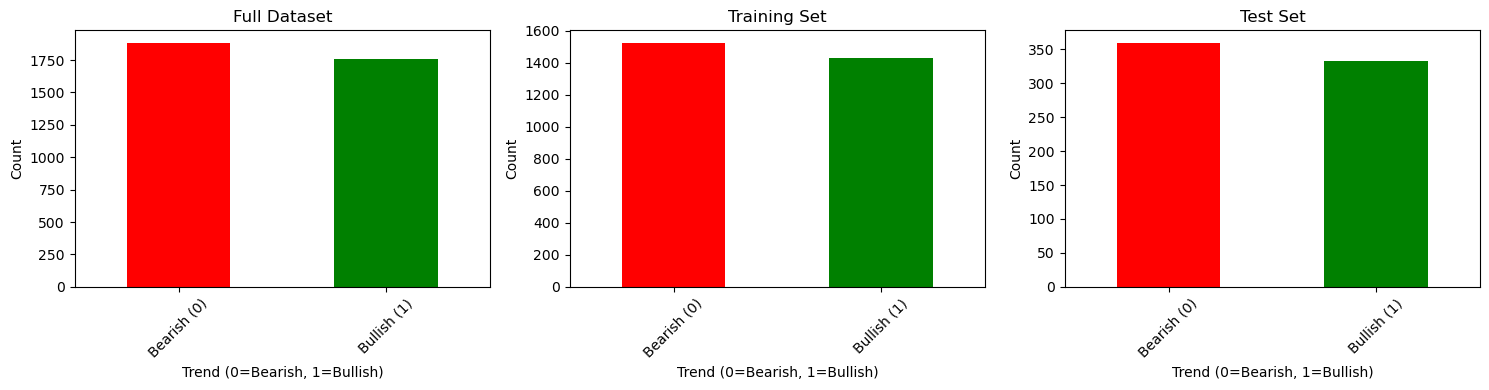

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

data["Trend"].value_counts().plot(kind='bar', ax=axes[0], color=['red', 'green'])
axes[0].set_title('Full Dataset')
axes[0].set_xlabel('Trend (0=Bearish, 1=Bullish)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Bearish (0)', 'Bullish (1)'], rotation=45)

y_train.value_counts().plot(kind='bar', ax=axes[1], color=['red', 'green'])
axes[1].set_title('Training Set')
axes[1].set_xlabel('Trend (0=Bearish, 1=Bullish)')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Bearish (0)', 'Bullish (1)'], rotation=45)

y_test.value_counts().plot(kind='bar', ax=axes[2], color=['red', 'green'])
axes[2].set_title('Test Set')
axes[2].set_xlabel('Trend (0=Bearish, 1=Bullish)')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels(['Bearish (0)', 'Bullish (1)'], rotation=45)

plt.tight_layout()
plt.show()

The class distribution analysis reveals that all datasets (full, training, and test sets) maintain a relatively balanced distribution between bearish (0) and bullish (1) trends, with approximately 48-49% bearish days and 51-52% bullish days. This near-equal distribution indicates that no class imbalance correction methods (such as SMOTE, class weights, or resampling techniques) are necessary, as the classes are naturally balanced. This balanced distribution allows our models to learn effectively from both classes without bias, ensuring fair and reliable trend predictions.

# Modelisation - Level 1

In [38]:
# just to see if the target "Trend" is ok
print("Available columns now :")
print(data.columns)

print("\nVisualisation de la Target créée :")
print(data['Trend'].value_counts())

Available columns now :
Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Return_1d', 'MA50', 'MA200',
       'Volatility_20d', 'RSI_14', 'Trend', 'ADX', 'MACD', 'BBL_High',
       'BBL_Low'],
      dtype='object')

Visualisation de la Target créée :
Trend
1    1885
0    1759
Name: count, dtype: int64


--- 1. Logistic regression visalization ---


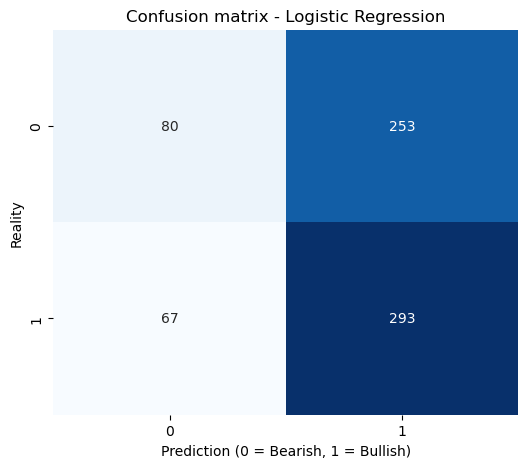

--------------------------------------------------

Detailed tab for log :
              precision    recall  f1-score   support

           0       0.54      0.24      0.33       333
           1       0.54      0.81      0.65       360

    accuracy                           0.54       693
   macro avg       0.54      0.53      0.49       693
weighted avg       0.54      0.54      0.50       693

--- Linear SVP detail ---
Accuracy SVM Linéaire : 51.95%

Detail report of the SVM :
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       333
           1       0.52      1.00      0.68       360

    accuracy                           0.52       693
   macro avg       0.26      0.50      0.34       693
weighted avg       0.27      0.52      0.36       693

--------------------------------------------------
Comparaison Level 1 :
LogReg Accuracy : 53.82%
SVM Accuracy    : 51.95%


c:\Users\TJN22\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\TJN22\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\TJN22\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

In [39]:


from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("--- 1. Logistic regression visalization ---")

# Train Logistic Regression model
log_reg = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for small datasets
log_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred = log_reg.predict(X_test_scaled)

# matrix confusion
cm_logreg = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion matrix - Logistic Regression')
plt.xlabel('Prediction (0 = Bearish, 1 = Bullish)')  #Bearish is going down, bullish is going up
plt.ylabel('Reality')
plt.show()

print("-" * 50)
print("\nDetailed tab for log :")
print(classification_report(y_test, y_pred))

# Linear svm part
print("--- Linear SVP detail ---")

# Creationg and svm training
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Rating
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy SVM Linéaire : {acc_svm:.2%}")

print("\nDetail report of the SVM :")
print(classification_report(y_test, y_pred_svm))

# Comparing the 2 models
print("-" * 50)
print(f"Comparaison Level 1 :")
print(f"LogReg Accuracy : {accuracy_score(y_test, y_pred):.2%}")
print(f"SVM Accuracy    : {acc_svm:.2%}")

The results of the basic models are really meaningfull, because the svm model looks at the numbers (more 1 to predict than 0), So it could'nt see a proper slope, thus to maximise its prediction (51.95 percents), he predicts 1 all the time. The log regression isn't perfect at all, but it catched 24 percents of the loss ( recall 0.24). That means globally that relations between price and indicators are non linear. So in the next part we will use better models like random forest and xg boost.

# Modelisation - Level 2

 Training no linear random forest alg
 Accuracy Random Forest : 46.75%

Detail report RF :
              precision    recall  f1-score   support

           0       0.46      0.55      0.50       333
           1       0.48      0.39      0.43       360

    accuracy                           0.47       693
   macro avg       0.47      0.47      0.47       693
weighted avg       0.47      0.47      0.46       693



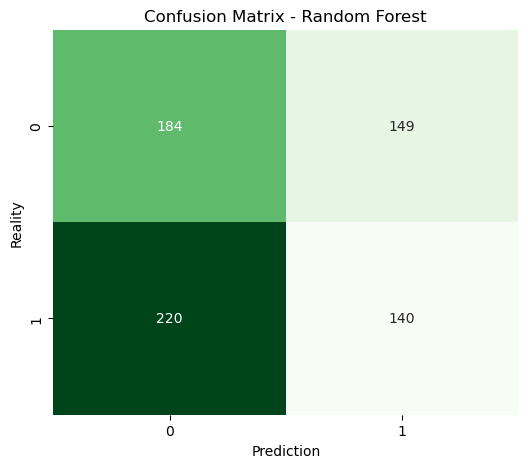


Indicators performance


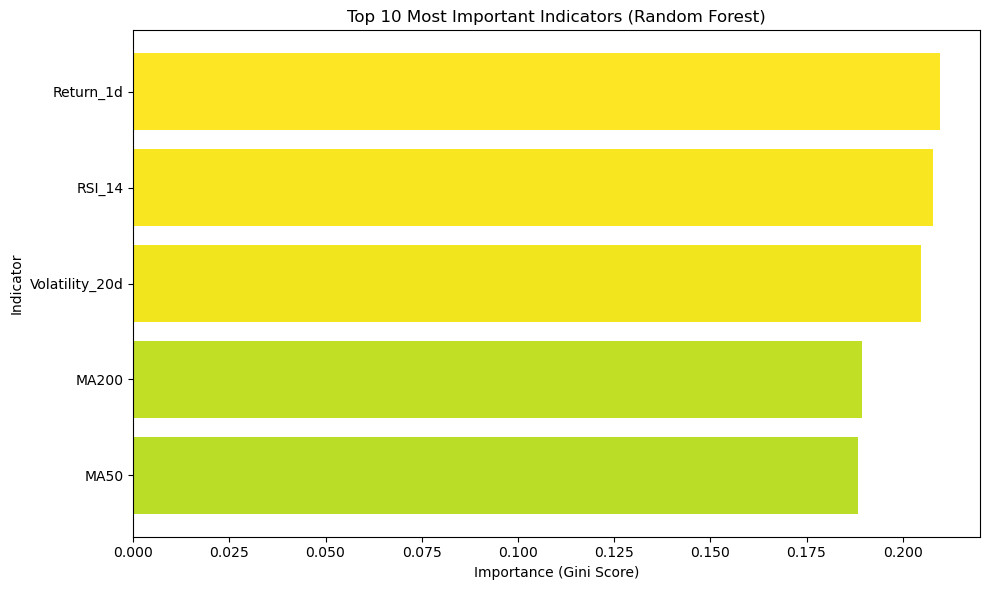

In [40]:
# We will give a first try using random forest which use bagging, a key tool in financial market trend analysis

from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(" Training no linear random forest alg")

# Configuration
# n_estimators=100 : We use 100 decision trees
# max_depth=None : We let the trees grow (attention to overfitting, we will adjust if necessary)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# training
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluation
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f" Accuracy Random Forest : {acc_rf:.2%}")
print("\nDetail report RF :")
print(classification_report(y_test, y_pred_rf))

# 5. Confusion Matrix (Visual comparison)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Prediction')
plt.ylabel('Reality')
plt.show()

# Features importance
print("\nIndicators performance")

# Getting the features importance
importances = rf_model.feature_importances_

# We try to retrieve the column names from the original X_train if possible.
# Otherwise, we assign generic names.
try:
    feature_names = X_train.columns
except:
    feature_names = [f"Feature {i}" for i in range(X_train_scaled.shape[1])]

# Creation of a DataFrame for the plot
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Plot using matplotlib with a viridis colormap to avoid seaborn palette warning
plt.figure(figsize=(10, 6))
# normalize importances for colormap
norm_vals = feature_imp_df['Importance'].values / feature_imp_df['Importance'].max()
colors = plt.cm.viridis(norm_vals)
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color=colors)
plt.gca().invert_yaxis()
plt.title('Top 10 Most Important Indicators (Random Forest)')
plt.xlabel('Importance (Gini Score)')
plt.ylabel('Indicator')
plt.tight_layout()
plt.show()


starting grid search
can take 1 or 2 Mins
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Optimisation is finished !
Best found parameters : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best score, intern validation : 50.35%
----------------------------------------
Accuracy on the test set : 48.92%

Matrice de Confusion (Modèle Optimisé) :


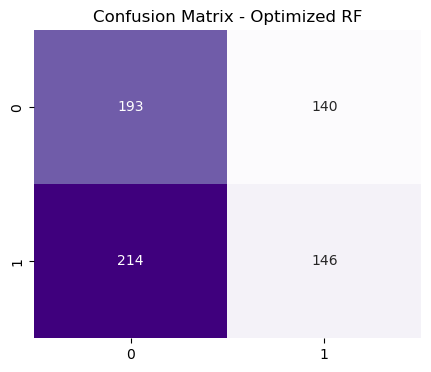

In [41]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

print("starting grid search")
print("can take 1 or 2 Mins")

# Definition of the tested grid
# testing different depths so it won't learn the noise ( overfitting )
param_grid = {
    'n_estimators': [100, 200],       # number of trees
    'max_depth': [5, 10, 20],         # Max depth, trying to not go too deep to avoid overfitting
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4]
}

# Grid search creation
# Cross validation in 3 blocks
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           n_jobs=-1,
                           verbose=1,
                           scoring='accuracy')

# training
grid_search.fit(X_train_scaled, y_train)

# results
print("\nOptimisation is finished !")
print(f"Best found parameters : {grid_search.best_params_}")
print(f"Best score, intern validation : {grid_search.best_score_:.2%}")

# Final validation on the test set
best_rf = grid_search.best_estimator_
y_pred_optimized = best_rf.predict(X_test_scaled)

acc_opt = accuracy_score(y_test, y_pred_optimized)
print("-" * 40)
print(f"Accuracy on the test set : {acc_opt:.2%}")

#Results
print("\nMatrice de Confusion (Modèle Optimisé) :")
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_optimized), annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Confusion Matrix - Optimized RF')
plt.show()


Testing XGBOOST
 Accuracy XGBoost : 49.35%

Detailed Report XGBoost :
              precision    recall  f1-score   support

           0       0.47      0.51      0.49       333
           1       0.51      0.48      0.49       360

    accuracy                           0.49       693
   macro avg       0.49      0.49      0.49       693
weighted avg       0.49      0.49      0.49       693


Confusion Matrix (Optimized Model) :


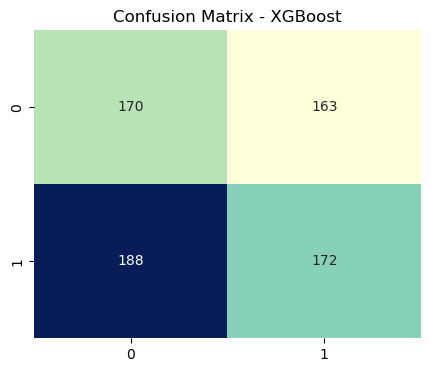

In [42]:
# XGBOOST

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\nTesting XGBOOST")

# We use the best found parameters used by grid search
# best_params = grid_search.best_params_ # Commenting out previous best_params for direct input

xgb_model = XGBClassifier(
    n_estimators=60,
    max_depth=5,
    min_child_weight=1,
    subsample=1,
    colsample_bytree=1,
    learning_rate=0.15,
    random_state=42,
    eval_metric='logloss'
)

# Training
xgb_model.fit(X_train_scaled, y_train)

# Prediction
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Rating
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f" Accuracy XGBoost : {acc_xgb:.2%}")

print("\nDetailed Report XGBoost :")
print(classification_report(y_test, y_pred_xgb))

# Confusion matrix
print("\nConfusion Matrix (Optimized Model) :")
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title('Confusion Matrix - XGBoost')
plt.show()

# Task
Add more advanced technical indicators such as MACD, Bollinger Bands, Stochastic Oscillator, ADX, and Ichimoku Kinko Hyo to the dataset using the 'ta' library, and then re-evaluate their impact on the stock trend prediction model.

##  Advanced Technical Indicators




In [43]:
import ta

# Calculate MACD
macd_indicator = ta.trend.MACD(close=data["Close"])
data["MACD"] = macd_indicator.macd()
data["MACD_Signal"] = macd_indicator.macd_signal()
data["MACD_Hist"] = macd_indicator.macd_diff()

# Calculate Bollinger Bands
bollinger_indicator = ta.volatility.BollingerBands(close=data["Close"])
data["BBL_High"] = bollinger_indicator.bollinger_hband()
data["BBL_Low"] = bollinger_indicator.bollinger_lband()
data["BBL_Mid"] = bollinger_indicator.bollinger_mavg()

# Calculate Stochastic Oscillator
stoch_indicator = ta.momentum.StochasticOscillator(high=data["High"], low=data["Low"], close=data["Close"])
data["STOCH_K"] = stoch_indicator.stoch()
data["STOCH_D"] = stoch_indicator.stoch_signal()

# Calculate Average Directional Index (ADX)
data["ADX"] = ta.trend.adx(high=data["High"], low=data["Low"], close=data["Close"])

# Calculate Ichimoku Kinko Hyo
ichimoku_indicator = ta.trend.IchimokuIndicator(high=data["High"], low=data["Low"])
data["Ichimoku_Conv"] = ichimoku_indicator.ichimoku_conversion_line()
data["Ichimoku_Base"] = ichimoku_indicator.ichimoku_base_line()
data["Ichimoku_A"] = ichimoku_indicator.ichimoku_a()
data["Ichimoku_B"] = ichimoku_indicator.ichimoku_b()

# Display the first few rows of the updated data DataFrame
print("\nFirst few rows of data with new technical indicators:")
print(data.head())

# Print the information about the data DataFrame
print("\nInfo of data with new technical indicators:")
print(data.info())


First few rows of data with new technical indicators:
               Close      High       Low      Open    Volume  Return_1d  \
Date                                                                      
2011-04-12  1.643333  1.680667  1.620000  1.672000  20361000  -0.024535   
2011-04-13  1.662000  1.712667  1.654000  1.675333  18172500   0.011359   
2011-04-14  1.676000  1.685333  1.613333  1.658000  14751000   0.008424   
2011-04-15  1.705333  1.745333  1.694000  1.710000  14152500   0.017502   
2011-04-18  1.668667  1.708000  1.624000  1.675333  15508500  -0.021501   

                MA50     MA200  Volatility_20d     RSI_14  ...  BBL_Low  \
Date                                                       ...            
2011-04-12  1.597293  1.581757        0.045385  49.263004  ...      NaN   
2011-04-13  1.598653  1.582103        0.045344  50.769372  ...      NaN   
2011-04-14  1.600253  1.582540        0.045328  51.922269  ...      NaN   
2011-04-15  1.602853  1.583747        0.0454

In [44]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Return_1d', 'MA50', 'MA200',
       'Volatility_20d', 'RSI_14', 'Trend', 'ADX', 'MACD', 'BBL_High',
       'BBL_Low', 'MACD_Signal', 'MACD_Hist', 'BBL_Mid', 'STOCH_K', 'STOCH_D',
       'Ichimoku_Conv', 'Ichimoku_Base', 'Ichimoku_A', 'Ichimoku_B'],
      dtype='object')

## Implement LightGBM Classifier



c:\Users\TJN22\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\TJN22\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


[LightGBM] [Info] Number of positive: 1506, number of negative: 1412
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001832 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4589
[LightGBM] [Info] Number of data points in the train set: 2918, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.516107 -> initscore=0.064450
[LightGBM] [Info] Start training from score 0.064450

--- LightGBM Model Performance ---
 Accuracy LightGBM: 52.24%

Rapport détaillé LightGBM:
              precision    recall  f1-score   support

           0       0.50      0.54      0.52       333
           1       0.54      0.51      0.52       360

    accuracy                           0.52       693
   macro avg       0.52      0.52      0.52       693
weighted avg       0.52      0.52      0.52       693



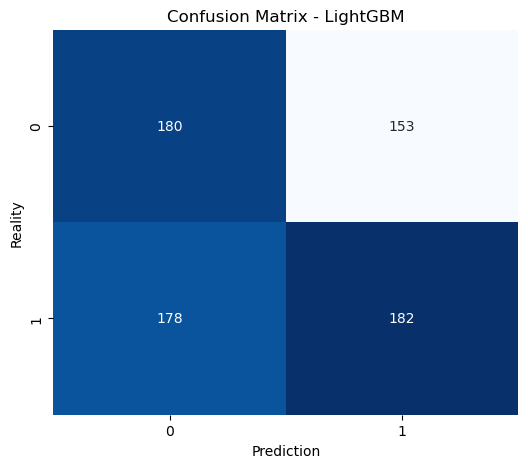

In [45]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the features for the LightGBM model, including the newly added advanced technical indicators.
# Make sure to exclude any columns with NaN values.
new_features = [
    "Return_1d", "MA50", "MA200", "Volatility_20d", "RSI_14",
    "MACD", "MACD_Signal", "MACD_Hist",
    "BBL_High", "BBL_Low", "BBL_Mid",
    "STOCH_K", "STOCH_D",
    "ADX",
    "Ichimoku_Conv", "Ichimoku_Base", "Ichimoku_A", "Ichimoku_B"
]
target = "Trend"

# 2. Drop rows with NaN values from the `data` DataFrame, if any remain after feature creation.
data_cleaned = data.dropna(subset=new_features + [target])

# 3. Split the data into training and testing sets using the same temporal split as before
train_new = data_cleaned.loc[: "2022-12-31"]
test_new = data_cleaned.loc["2023-01-01":]

X_train_new = train_new[new_features]
y_train_new = train_new[target]

X_test_new = test_new[new_features]
y_test_new = test_new[target]

#Initialize a StandardScaler object and fit it only to X_train_new.
scaler_new = StandardScaler()
scaler_new.fit(X_train_new)

#Transform both X_train_new and X_test_new using the fitted scaler.
X_train_scaled_new = scaler_new.transform(X_train_new)
X_test_scaled_new = scaler_new.transform(X_test_new)

# Convert scaled arrays back to DataFrames for consistency and easier handling
X_train_scaled_new = pd.DataFrame(X_train_scaled_new, columns=new_features, index=X_train_new.index)
X_test_scaled_new = pd.DataFrame(X_test_scaled_new, columns=new_features, index=X_test_new.index)

# Import LGBMClassifier from lightgbm (already done at the top)

# Instantiate an LGBMClassifier with random_state=42.
lgbm_model = lgb.LGBMClassifier(random_state=42)

# Train the LGBMClassifier on the scaled training data.
lgbm_model.fit(X_train_scaled_new, y_train_new)

#Make predictions on the scaled test data.
y_pred_lgbm = lgbm_model.predict(X_test_scaled_new)

# Calculate and print the accuracy score and the classification report.
print("\n--- LightGBM Model Performance ---")
acc_lgbm = accuracy_score(y_test_new, y_pred_lgbm)
print(f" Accuracy LightGBM: {acc_lgbm:.2%}")
print("\nRapport détaillé LightGBM:")
print(classification_report(y_test_new, y_pred_lgbm))

#Generate and display a confusion matrix for the LightGBM model.
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_new, y_pred_lgbm), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - LightGBM')
plt.xlabel('Prediction')
plt.ylabel('Reality')
plt.show()


## Hyperparameter Tuning for LightGBM with Time Series Cross-Validation




--- Hyperparameter Tuning for LightGBM with Time Series Cross-Validation ---
Fitting GridSearchCV for LightGBM...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
[LightGBM] [Info] Number of positive: 1506, number of negative: 1412
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000745 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4589
[LightGBM] [Info] Number of data points in the train set: 2918, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.516107 -> initscore=0.064450
[LightGBM] [Info] Start training from score 0.064450
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

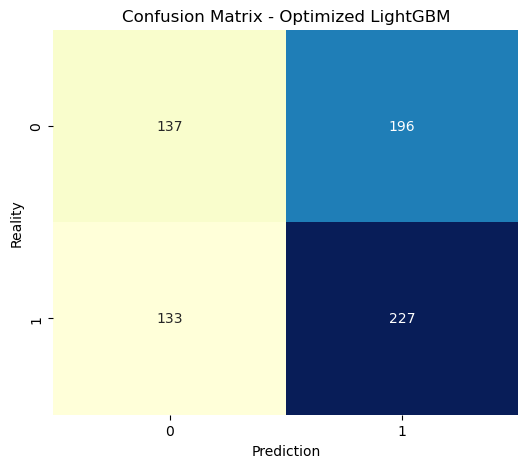

In [46]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Hyperparameter Tuning for LightGBM with Time Series Cross-Validation ---")

#  the parameter grid for LGBMClassifier
param_grid_lgbm = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 40],
    'min_child_samples': [20, 30, 40]
}

#  Initialize TimeSeriesSplit
# Our dataset X_train_scaled_new has about 2900 samples.
# With n_splits=5, we create 5 splits: each time, around 1/6 of the data is used for validation,
# and the rest is used for training, which grows step by step.
# The max_train_size parameter can limit how big the training set gets.
# If we don’t set it, the training set can become very large and make later folds slow to train.
# Here, since our dataset isn’t huge, we leave max_train_size=None
# so the training set grows naturally with each split.

tscv = TimeSeriesSplit(n_splits=5)

#  Create a GridSearchCV object
grid_search_lgbm = GridSearchCV(
    estimator=lgb.LGBMClassifier(random_state=42),
    param_grid=param_grid_lgbm,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1, # Use all available cores
    verbose=1
)

#  Fit the GridSearchCV object to the scaled training data
print("Fitting GridSearchCV for LightGBM...")
grid_search_lgbm.fit(X_train_scaled_new, y_train_new)
print("GridSearchCV fitting complete.")

#  Print the best parameters found
print(f"\nBest parameters found: {grid_search_lgbm.best_params_}")

#  Print the best score achieved during cross-validation
print(f"Best cross-validation accuracy: {grid_search_lgbm.best_score_:.2%}")

#  Get the best estimator
best_lgbm_model = grid_search_lgbm.best_estimator_

#  Make predictions on the scaled test data
y_pred_lgbm_tuned = best_lgbm_model.predict(X_test_scaled_new)

# Calculate and print the accuracy score and the classification report
print("\n--- Optimized LightGBM Model Performance on Test Set ---")
acc_lgbm_tuned = accuracy_score(y_test_new, y_pred_lgbm_tuned)
print(f" Accuracy Optimized LightGBM: {acc_lgbm_tuned:.2%}")
print("\nRapport détaillé Optimized LightGBM:")
print(classification_report(y_test_new, y_pred_lgbm_tuned))

#  Generate and display a confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_new, y_pred_lgbm_tuned), annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title('Confusion Matrix - Optimized LightGBM')
plt.xlabel('Prediction')
plt.ylabel('Reality')
plt.show()

## Creating and testing the 5 d trend def



Defining ‘Trend’ only by checking if the next day’s closing price is higher than today’s can be too sensitive to short-term noise and random fluctuations. This makes it unstable and not very reliable for prediction, since it only reflects immediate changes instead of the overall market direction. Using a trend definition over a slightly longer time period could give a clearer and more consistent signal for our models


Full dataset class distribution for 'Trend_5d_ahead':
Trend_5d_ahead
1    1950
0    1661
Name: count, dtype: int64

Percentage:
Trend_5d_ahead
1    54.001662
0    45.998338
Name: proportion, dtype: float64

Training set class distribution for 'Trend_5d_ahead':
Trend_5d_ahead
1    1590
0    1328
Name: count, dtype: int64

Percentage:
Trend_5d_ahead
1    54.489376
0    45.510624
Name: proportion, dtype: float64

Test set class distribution for 'Trend_5d_ahead':
Trend_5d_ahead
1    360
0    333
Name: count, dtype: int64

Percentage:
Trend_5d_ahead
1    51.948052
0    48.051948
Name: proportion, dtype: float64


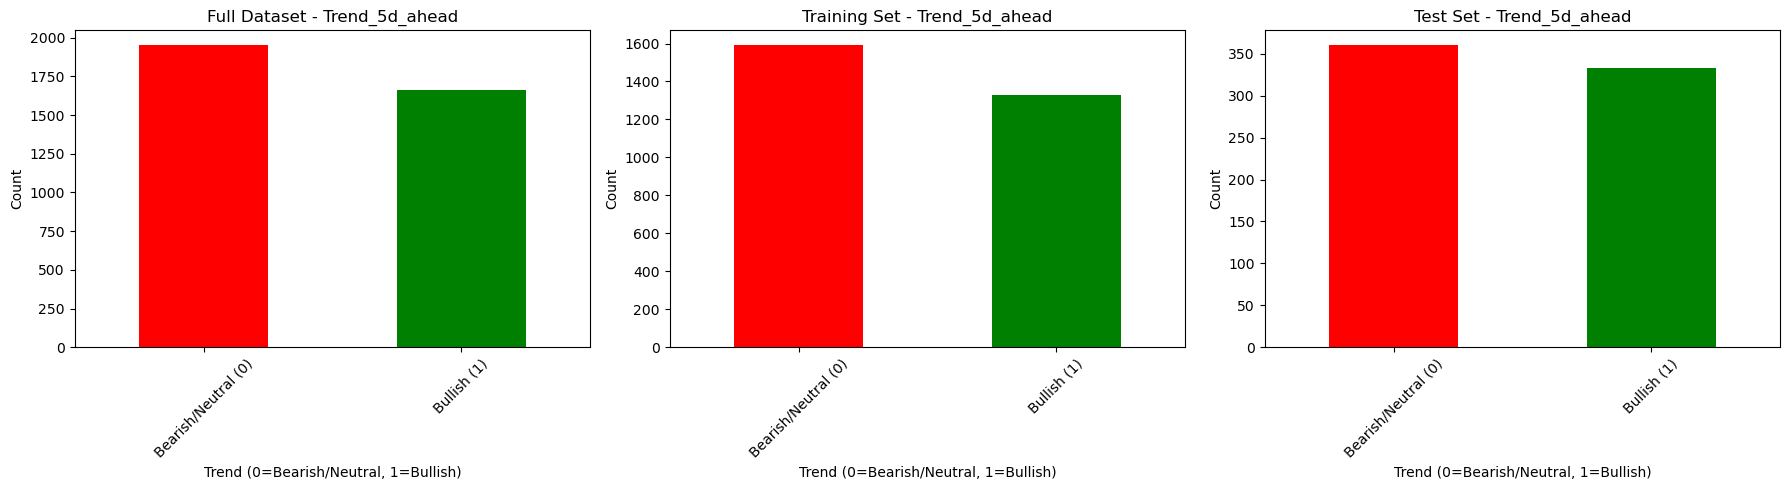

In [47]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Creating Trend_5d_ahead.
data['Trend_5d_ahead'] = (data['Close'].shift(-5) > data['Close']).astype(int)

# Remove any rows from the data DataFrame that now contain NaN values.
# It  will drop rows where `Trend_5d_ahead` (and potentially other indicators) are NaN.
data_cleaned = data.dropna()

# `target` variable string to 'Trend_5d_ahead'.
target_new = "Trend_5d_ahead"

# Redefine features
new_features = [
    "Return_1d", "MA50", "MA200", "Volatility_20d", "RSI_14",
    "MACD", "MACD_Signal", "MACD_Hist",
    "BBL_High", "BBL_Low", "BBL_Mid",
    "STOCH_K", "STOCH_D",
    "ADX",
    "Ichimoku_Conv", "Ichimoku_Base", "Ichimoku_A", "Ichimoku_B"
]

# Dropping nans
# It's possible some indicators (like MACD, Bollinger Bands) have NaNs for the first few rows


#train-test split again using the data_cleaned DataFrame
train_new = data_cleaned.loc[: "2022-12-31"]
test_new = data_cleaned.loc["2023-01-01":]

X_train_new = train_new[new_features]
y_train_new = train_new[target_new]

X_test_new = test_new[new_features]
y_test_new = test_new[target_new]

# Re-scale the X_train_new and X_test_new features
scaler_new = StandardScaler()
scaler_new.fit(X_train_new)

X_train_scaled_new = scaler_new.transform(X_train_new)
X_test_scaled_new = scaler_new.transform(X_test_new)

X_train_scaled_new = pd.DataFrame(
    X_train_scaled_new,
    columns=new_features,
    index=X_train_new.index
)

X_test_scaled_new = pd.DataFrame(
    X_test_scaled_new,
    columns=new_features,
    index=X_test_new.index
)

# Print the class distribution for the new `Trend_5d_ahead` variable
print("\nFull dataset class distribution for 'Trend_5d_ahead':")
print(data_cleaned[target_new].value_counts())
print("\nPercentage:")
print(data_cleaned[target_new].value_counts(normalize=True) * 100)

print("\nTraining set class distribution for 'Trend_5d_ahead':")
print(y_train_new.value_counts())
print("\nPercentage:")
print(y_train_new.value_counts(normalize=True) * 100)

print("\nTest set class distribution for 'Trend_5d_ahead':")
print(y_test_new.value_counts())
print("\nPercentage:")
print(y_test_new.value_counts(normalize=True) * 100)

#generate and display bar plots to visualize the class distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

data_cleaned[target_new].value_counts().plot(kind='bar', ax=axes[0], color=['red', 'green'])
axes[0].set_title('Full Dataset - Trend_5d_ahead')
axes[0].set_xlabel('Trend (0=Bearish/Neutral, 1=Bullish)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Bearish/Neutral (0)', 'Bullish (1)'], rotation=45)

y_train_new.value_counts().plot(kind='bar', ax=axes[1], color=['red', 'green'])
axes[1].set_title('Training Set - Trend_5d_ahead')
axes[1].set_xlabel('Trend (0=Bearish/Neutral, 1=Bullish)')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Bearish/Neutral (0)', 'Bullish (1)'], rotation=45)

y_test_new.value_counts().plot(kind='bar', ax=axes[2], color=['red', 'green'])
axes[2].set_title('Test Set - Trend_5d_ahead')
axes[2].set_xlabel('Trend (0=Bearish/Neutral, 1=Bullish)')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels(['Bearish/Neutral (0)', 'Bullish (1)'], rotation=45)

plt.tight_layout()
plt.show()

## LightGBM Classifier (with new Trend_5d_ahead target)




---  LightGBM with new 'Trend_5d_ahead' target ---
[LightGBM] [Info] Number of positive: 1590, number of negative: 1328
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008878 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4589
[LightGBM] [Info] Number of data points in the train set: 2918, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.544894 -> initscore=0.180060
[LightGBM] [Info] Start training from score 0.180060

--- LightGBM Model Performance (new target) ---
 Accuracy LightGBM (new target): 51.52%

Rapport détaillé LightGBM (new target):
              precision    recall  f1-score   support

           0       0.50      0.56      0.52       333
           1       0.54      0.48      0.51       360

    accuracy                           0.52       693
   macro avg       0.52      0.52      0.51       693
weighted avg       0.52      0.52      0.51       693



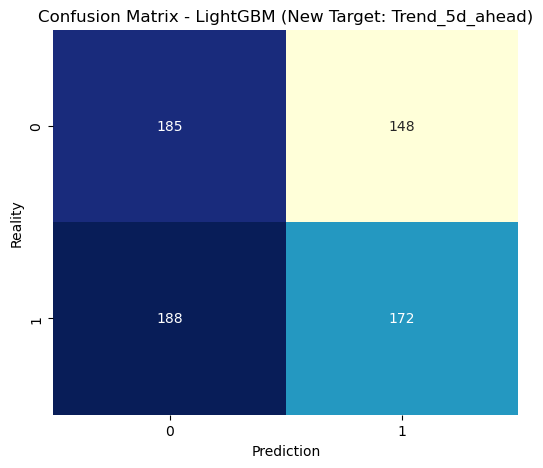

In [48]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\n---  LightGBM with new 'Trend_5d_ahead' target ---")

# Instantiate an LGBMClassifier with random_state=42.
lgbm_model_new_target = lgb.LGBMClassifier(random_state=42)

# Train the LGBMClassifier on the scaled training data (with new target).
lgbm_model_new_target.fit(X_train_scaled_new, y_train_new)

# Make predictions on the scaled test data.
y_pred_lgbm_new_target = lgbm_model_new_target.predict(X_test_scaled_new)

# Calculate and print the accuracy score.
print("\n--- LightGBM Model Performance (new target) ---")
acc_lgbm_new_target = accuracy_score(y_test_new, y_pred_lgbm_new_target)
print(f" Accuracy LightGBM (new target): {acc_lgbm_new_target:.2%}")

# Print the classification report.
print("\nRapport détaillé LightGBM (new target):")
print(classification_report(y_test_new, y_pred_lgbm_new_target))

# Generate and display a confusion matrix.
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_new, y_pred_lgbm_new_target), annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title('Confusion Matrix - LightGBM (New Target: Trend_5d_ahead)')
plt.xlabel('Prediction')
plt.ylabel('Reality')
plt.show()


# Testing with new trend variable 
with more rules and also 3 value (-1 = bearish, 0 = ranging, 1 = bullish)

In [49]:
data.drop(columns=['Trend_5d_ahead'], inplace=True)

We came to a conclusion that having too much indicators would only create more noise so we created a function to get minimal indicators and created a new trend variable corelated with other variables and not only the daily return.

## Exploring a New Multi-Class Trend Definition

Previously, we defined trend as a simple binary classification (up or down) based on the next day's price movement. However, this approach was too sensitive to short-term noise and didn't capture meaningful market trends. To address this limitation, we introduce a more sophisticated three-class trend definition:

### New Trend Classification Strategy

We now classify trends into three categories over a 25-day horizon:
- **Bullish (+1)**: Future return > +0.5% (significant upward movement)
- **Ranging (0)**: Future return between -0.5% and +0.5% (sideways/consolidation)
- **Bearish (-1)**: Future return < -0.5% (significant downward movement)

This approach offers several advantages:
1. **Reduced noise**: By using a 25-day horizon and threshold of ±0.5%, we filter out daily fluctuations
2. **More actionable signals**: Identifies clear directional trends rather than minor price changes
3. **Realistic market behavior**: Recognizes that markets don't always move up or down—they also consolidate
4. **Better risk management**: Traders can adjust strategies based on three distinct market conditions

The thresholds and horizon were chosen to balance between capturing meaningful trends and maintaining enough data points for each class to train our models effectively.

In [76]:
def build_target_future_trend(df: pd.DataFrame, horizon: int = 5):
    df = df.copy()

    # Retour futur sur N jours
    df["Future_Return_5d"] = df["Close"].shift(-horizon) / df["Close"] - 1

    # On drop les lignes où le futur n’existe pas
    df = df.dropna(subset=["Future_Return_5d"])

    # Cible en 3 classes équilibrées via quantiles
    df["Trend"] = 0
    df.loc[df["Future_Return_5d"] > 0.005, "Trend"] = 1    # +0.5%
    df.loc[df["Future_Return_5d"] < -0.005, "Trend"] = -1   # -0.5%

    return df

In [106]:
prepared_data = build_target_future_trend(data, horizon= 25)

In [107]:
prepared_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Return_1d', 'MA50', 'MA200',
       'Volatility_20d', 'RSI_14', 'Trend', 'ADX', 'MACD', 'BBL_High',
       'BBL_Low', 'MACD_Signal', 'MACD_Hist', 'BBL_Mid', 'STOCH_K', 'STOCH_D',
       'Ichimoku_Conv', 'Ichimoku_Base', 'Ichimoku_A', 'Ichimoku_B',
       'Future_Return_5d'],
      dtype='object')

In [108]:
prepared_data.head()

,Close,High,Low,Open,Volume,Return_1d,MA50,MA200,Volatility_20d,RSI_14,...,MACD_Signal,MACD_Hist,BBL_Mid,STOCH_K,STOCH_D,Ichimoku_Conv,Ichimoku_Base,Ichimoku_A,Ichimoku_B,Future_Return_5d
Date,,,,,,,,,,,,,,,,,,,,,
2011-04-12,1.643333,1.680667,1.620000,1.672000,20361000,-0.024535,1.597293,1.581757,0.045385,49.263004,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.650334,0.068966
2011-04-13,1.662000,1.712667,1.654000,1.675333,18172500,0.011359,1.598653,1.582103,0.045344,50.769372,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.666333,0.131167
2011-04-14,1.676000,1.685333,1.613333,1.658000,14751000,0.008424,1.600253,1.582540,0.045328,51.922269,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.663000,0.112570
2011-04-15,1.705333,1.745333,1.694000,1.710000,14152500,0.017502,1.602853,1.583747,0.045404,54.335217,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.679333,0.048476
2011-04-18,1.668667,1.708000,1.624000,1.675333,15508500,-0.021501,1.604947,1.585690,0.045693,50.896591,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.679333,0.067519


In [109]:
# `target` variable string to 'Trend_5d_ahead'.
target_new = "Trend"

# Redefine features
new_features = ['Close', 'High', 'Low', 'Open', 'Volume', 'Return_1d', 'MA50', 'MA200',
       'Volatility_20d', 'RSI_14', 'ADX', 'MACD', 'BBL_High',
       'BBL_Low', 'MACD_Signal', 'MACD_Hist', 'BBL_Mid', 'STOCH_K', 'STOCH_D',
       'Ichimoku_Conv', 'Ichimoku_Base', 'Ichimoku_A', 'Ichimoku_B']

#train-test split again using the data_cleaned DataFrame
train_new = prepared_data.loc[: "2022-12-31"]
test_new = prepared_data.loc["2023-01-01":]

In [110]:
X_train_new = train_new[new_features]
y_train_new = train_new[target_new]

X_test_new = test_new[new_features]
y_test_new = test_new[target_new]

# Re-scale the X_train_new and X_test_new features
scaler_new = StandardScaler()
scaler_new.fit(X_train_new)

X_train_scaled_new = scaler_new.transform(X_train_new)
X_test_scaled_new = scaler_new.transform(X_test_new)

X_train_scaled_new = pd.DataFrame(
    X_train_scaled_new,
    columns=new_features,
    index=X_train_new.index
)

X_test_scaled_new = pd.DataFrame(
    X_test_scaled_new,
    columns=new_features,
    index=X_test_new.index
)


Full dataset class distribution for 'Trend':
Trend
-1    1555
 0      76
 1    1988
Name: count, dtype: int64

Percentage:
Trend
-1    42.967671
 0     2.100028
 1    54.932302
Name: proportion, dtype: float64

Training set class distribution for 'Trend':
Trend
-1    1254
 0      66
 1    1631
Name: count, dtype: int64

Percentage:
Trend
-1    42.49407
 0     2.23653
 1    55.26940
Name: proportion, dtype: float64

Test set class distribution for 'Trend':
Trend
-1    301
 0     10
 1    357
Name: count, dtype: int64

Percentage:
Trend
-1    45.059880
 0     1.497006
 1    53.443114
Name: proportion, dtype: float64


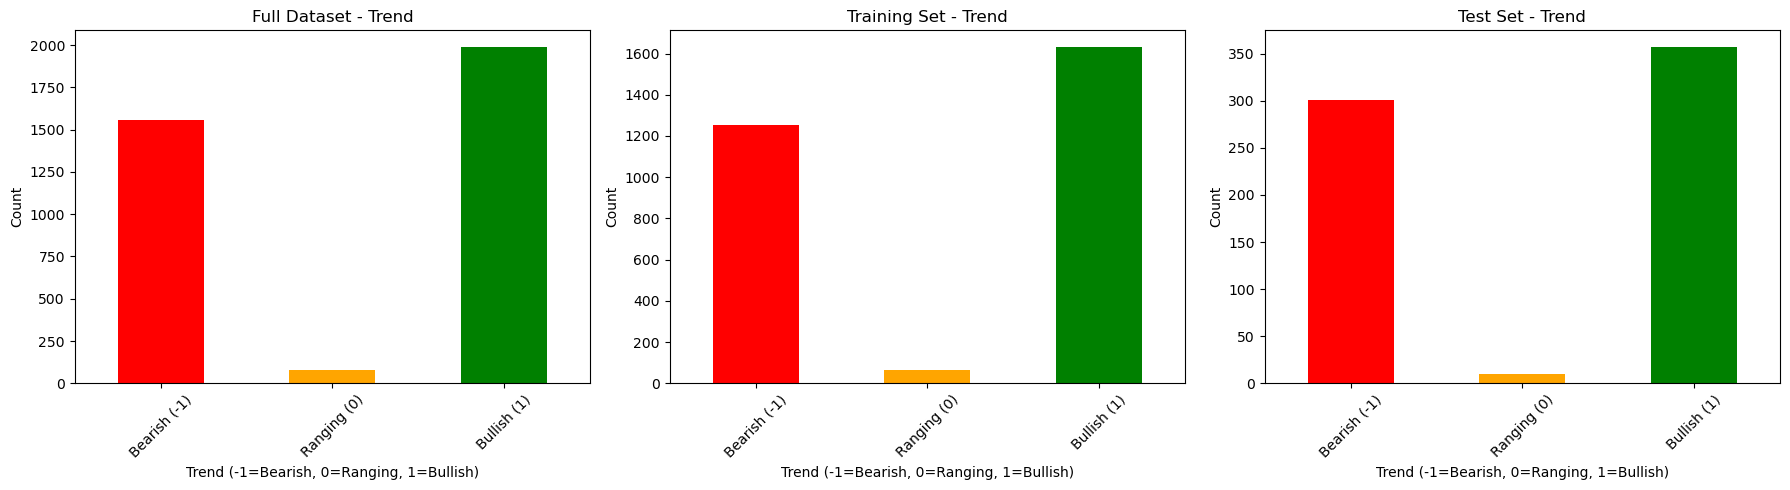

In [111]:
# Print the class distribution for the new `Trend` variable
print("\nFull dataset class distribution for 'Trend':")
print(prepared_data[target_new].value_counts().sort_index())
print("\nPercentage:")
print(prepared_data[target_new].value_counts(normalize=True).sort_index() * 100)

print("\nTraining set class distribution for 'Trend':")
print(y_train_new.value_counts().sort_index())
print("\nPercentage:")
print(y_train_new.value_counts(normalize=True).sort_index() * 100)

print("\nTest set class distribution for 'Trend':")
print(y_test_new.value_counts().sort_index())
print("\nPercentage:")
print(y_test_new.value_counts(normalize=True).sort_index() * 100)

# Generate and display bar plots to visualize the class distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

prepared_data[target_new].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['red', 'orange', 'green'])
axes[0].set_title('Full Dataset - Trend')
axes[0].set_xlabel('Trend (-1=Bearish, 0=Ranging, 1=Bullish)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Bearish (-1)', 'Ranging (0)', 'Bullish (1)'], rotation=45)

y_train_new.value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['red', 'orange', 'green'])
axes[1].set_title('Training Set - Trend')
axes[1].set_xlabel('Trend (-1=Bearish, 0=Ranging, 1=Bullish)')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Bearish (-1)', 'Ranging (0)', 'Bullish (1)'], rotation=45)

y_test_new.value_counts().sort_index().plot(kind='bar', ax=axes[2], color=['red', 'orange', 'green'])
axes[2].set_title('Test Set - Trend')
axes[2].set_xlabel('Trend (-1=Bearish, 0=Ranging, 1=Bullish)')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels(['Bearish (-1)', 'Ranging (0)', 'Bullish (1)'], rotation=45)

plt.tight_layout()
plt.show()



--- LightGBM with new 'Trend' target (3-class: -1, 0, 1) ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,001267 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5864
[LightGBM] [Info] Number of data points in the train set: 2951, number of used features: 23
[LightGBM] [Info] Start training from score -0,855806
[LightGBM] [Info] Start training from score -3,800245
[LightGBM] [Info] Start training from score -0,592951

--- LightGBM Model Performance (new target) ---
 Accuracy LightGBM (new target): 59.43%

Rapport détaillé LightGBM (new target):
              precision    recall  f1-score   support

          -1       0.59      0.42      0.49       301
           0       0.00      0.00      0.00        10
           1       0.60      0.76      0.67       357

    accuracy                           0.59       668
   macro avg       0.40      0.39      0.39       668
weighted avg       0.58      0.5

c:\Users\TJN22\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\TJN22\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\TJN22\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

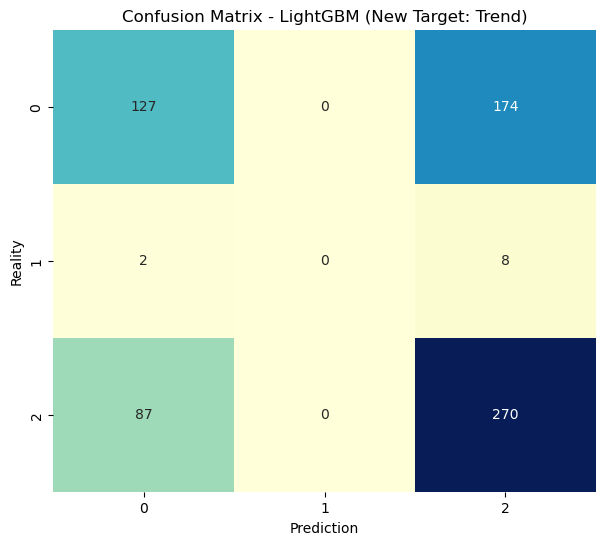

In [112]:
print("\n--- LightGBM with new 'Trend' target (3-class: -1, 0, 1) ---")

# Instantiate an LGBMClassifier with random_state=42.
lgbm_model_new_target = lgb.LGBMClassifier(random_state=42)

# Train the LGBMClassifier on the scaled training data (with new target).
lgbm_model_new_target.fit(X_train_scaled_new, y_train_new)

# Make predictions on the scaled test data.
y_pred_lgbm_new_target = lgbm_model_new_target.predict(X_test_scaled_new)

# Calculate and print the accuracy score.
print("\n--- LightGBM Model Performance (new target) ---")
acc_lgbm_new_target = accuracy_score(y_test_new, y_pred_lgbm_new_target)
print(f" Accuracy LightGBM (new target): {acc_lgbm_new_target:.2%}")

# Print the classification report.
print("\nRapport détaillé LightGBM (new target):")
print(classification_report(y_test_new, y_pred_lgbm_new_target))

# Generate and display a confusion matrix.
plt.figure(figsize=(7, 6))
sns.heatmap(confusion_matrix(y_test_new, y_pred_lgbm_new_target), annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title('Confusion Matrix - LightGBM (New Target: Trend)')
plt.xlabel('Prediction')
plt.ylabel('Reality')
plt.show()
